In [2]:
from typing import List, TypedDict

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from sentence_transformers import CrossEncoder
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
docs = (
    PyPDFLoader("documents\Corporate_Policy_Compendium_Vol1.pdf").load() +
    PyPDFLoader("documents\Corporate_Policy_Compendium_Vol2.pdf").load()
)

In [5]:
len(docs)

402

In [6]:
docs[0].metadata

{'producer': 'WeasyPrint 62.3',
 'creator': 'PyPDF',
 'creationdate': '',
 'source': 'documents\\Corporate_Policy_Compendium_Vol1.pdf',
 'total_pages': 201,
 'page': 0,
 'page_label': '1'}

In [7]:
docs[50].page_content

'Supervisors and managers bear the primary responsibility for ensuring that their respective\nteams understand and execute the actions described herein. Regular audits and reviews will\nbe conducted to measure compliance and identify areas requiring supplemental training.\nAll data handled under this purview must be treated with the highest level of confidentiality.\nUnauthorized  dissemination,  duplication,  or  transmission  of  proprietary  information\ncompromises our strategic advantage and violates the trust placed in our workforce.\nEmployees utilizing company assets, whether digital or physical, must do so exclusively for\napproved  business  purposes.  Personal  use  of  these  resources  is  heavily  restricted  and\nmonitored to ensure bandwidth and asset integrity are preserved for core business functions.\nProcedures\nDirective: Step-by-step instructions on how to follow the policy or actions needed to comply.\nIn the event of a breach or perceived violation, individuals 

In [8]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [9]:
len(chunks)

1054

In [10]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

C:\Users\Agnivo\AppData\Local\Temp\ipykernel_29508\4246038141.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [12]:
# 4) LLM + prompt
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
def rewrite_query(user_query):
    prompt = f"""
    Rewrite the following query to make it more detailed and specific for document retrieval.
    donot change the meaning of actual query

    Query: {user_query}

    Rewritten Query:
    """

    response = llm.invoke(prompt)
    return response.text()

In [13]:
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
class State(TypedDict):
    question: str
    rewritten_query: str
    docs: List[Document]
    answer: str

In [15]:
def rerank_documents(query, docs):
    pairs = [(query, doc.page_content) for doc in docs]

    scores = reranker.predict(pairs)

    # attach scores
    doc_scores = list(zip(docs, scores))

    # sort by score (descending)
    doc_scores.sort(key=lambda x: x[1], reverse=True)

    # return top 5 docs
    return doc_scores[:5]

In [16]:
def retrieve(state):
    original_q = state["question"]
    rewritten_q = rewrite_query(original_q)
    docs = vector_store.similarity_search(rewritten_q, k=15)
    # Step 2: rerank
    reranked = rerank_documents(original_q, docs)
    print("\n RERANKING RESULTS:\n")

    final_docs = []

    for i, (doc, score) in enumerate(reranked):
        print(f"Rank {i+1} | Score: {score:.4f}")
        print(doc.page_content[:200])
        print("-" * 50)

        final_docs.append(doc)

    return {
        "docs": final_docs,
        "rewritten_query": rewritten_q
    }

In [17]:

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}


In [18]:
from langgraph.graph import StateGraph,START,END

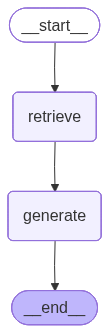

In [19]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [22]:
# 5) Run
res = app.invoke({"question": "what are the Health and Safety (OHS) policy in the company?", "docs": [], "answer": "","rewritten_query":{}})

C:\Users\Agnivo\AppData\Local\Temp\ipykernel_29508\1772607108.py:3: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  rewritten_q = rewrite_query(original_q)



 RERANKING RESULTS:

Rank 1 | Score: 6.6919
Section 131: Health and Safety (OHS)
Strategic Benefit: Legal Protection: Shields the company from potential legal issues and lawsuits. 
Policy Guidelines
Directive: The specific rules and expected be
--------------------------------------------------
Rank 2 | Score: 6.3220
Section 103: Health and Safety (OHS)
Strategic Benefit: Legal Protection: Shields the company from potential legal issues and lawsuits. 
Policy Guidelines
Directive: The specific rules and expected be
--------------------------------------------------
Rank 3 | Score: 6.3073
Section 1: Health and Safety (OHS)
Strategic Benefit: Clarification of Values: Reflects the culture and ethical standards of the company. 
Scope
Directive: A definition of who the policy applies to (e
--------------------------------------------------
Rank 4 | Score: 6.0181
Section 47: Health and Safety (OHS)
Strategic Benefit: Legal Protection: Shields the company from potential legal issues and lawsu

In [23]:
res["question"]

'what are the Health and Safety (OHS) policy in the company?'

In [24]:
res["rewritten_query"]

'Here are a few options for rewriting the query to be more detailed and specific for document retrieval, while maintaining the original meaning:\n\n**Option 1 (Focus on specific document types):**\n\n> Retrieve documents detailing the company\'s official Occupational Health and Safety (OHS) policy, including any associated procedures, guidelines, or statements.\n\n**Option 2 (Adding context about purpose):**\n\n> Provide the company\'s comprehensive policy document(s) outlining its commitment to and framework for Occupational Health and Safety (OHS) management.\n\n**Option 3 (More direct and action-oriented):**\n\n> Locate and present the company\'s documented Occupational Health and Safety (OHS) policy.\n\n**Option 4 (Slightly more formal):**\n\n> I am seeking the formal policy document(s) that govern Occupational Health and Safety (OHS) within the organization.\n\n**Option 5 (Emphasizing comprehensiveness):**\n\n> Please provide the complete set of documents that constitute the compa

In [25]:
res["answer"]

"The Health and Safety (OHS) policy in the company includes the following:\n\n*   **Legal Protection:** Shields the company from potential legal issues and lawsuits.\n*   **Clarification of Values:** Reflects the culture and ethical standards of the company.\n*   **Consistency:** Ensures that all employees are treated fairly and uniformly across departments.\n*   **Document Retention:** All documented procedures must be retained in the company's secure archives for a minimum of seven years following their supersession or retirement, in accordance with local and federal regulations.\n*   **Continuous Improvement:** Policies are subject to periodic review and modification to align with evolving legal standards, industry best practices, and organizational goals.\n*   **Managerial Responsibility:** Supervisors and managers are primarily responsible for ensuring their teams understand and execute the described actions. Regular audits and reviews will be conducted to measure compliance and i

In [ ]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)